# Hate Speech Detection

In [2]:
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import string
import nltk
nltk.download('stopwords')
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
%matplotlib inline

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
dataset = pd.read_csv("HateSpeechData.csv")
dataset

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...
...,...,...,...,...,...,...,...
24778,25291,3,0,2,1,1,you's a muthaf***in lie &#8220;@LifeAsKing: @2...
24779,25292,3,0,1,2,2,"you've gone and broke the wrong heart baby, an..."
24780,25294,3,0,3,0,1,young buck wanna eat!!.. dat nigguh like I ain...
24781,25295,6,0,6,0,1,youu got wild bitches tellin you lies


count
number of CrowdFlower users who coded each tweet (min is 3, sometimes more users coded a tweet when judgments were determined to be unreliable by CF)

hate speech
number of CF users who judged the tweet to be hate speech

offensive_language
number of CF users who judged the tweet to be offensive

neither
number of CF users who judged the tweet to be neither offensive nor non-offensive

class
label for majority of CF users. 0 - hate speech 1 - offensive language 2 - neither

In [4]:
# Adding text-length as a field in the dataset
dataset['text length'] = dataset['tweet'].apply(len)
print(dataset.head())

   Unnamed: 0  count  hate_speech  offensive_language  neither  class  \
0           0      3            0                   0        3      2   
1           1      3            0                   3        0      1   
2           2      3            0                   3        0      1   
3           3      3            0                   2        1      1   
4           4      6            0                   6        0      1   

                                               tweet  text length  
0  !!! RT @mayasolovely: As a woman you shouldn't...          140  
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...           85  
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...          120  
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...           62  
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...          137  


<Axes: >

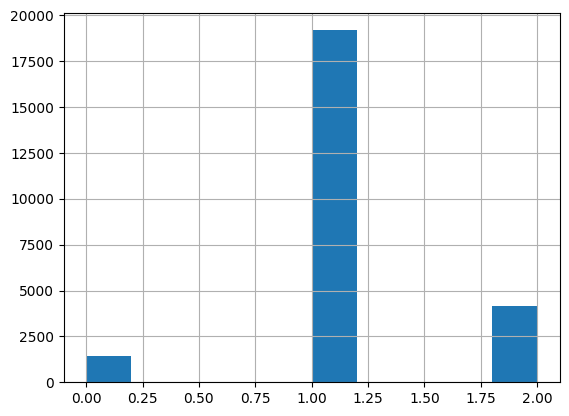

In [5]:
dataset['class'].hist()

The above histogram shows that most of the tweets are considered to be offensive words by the CF coders.

## Preprocessing of the tweets

In [6]:
# Initialize stopwords and add Twitter-specific terms (retweet, follow friday)
stop_words = set(stopwords.words("english"))
other_exclusions = ["#ff", "ff", "rt"]
stop_words.update(other_exclusions)

stemmer = PorterStemmer()

def preprocess(tweet):

    #  Remove @mentions
    tweet = re.sub(r'@[\w\-]+', '', tweet)

    # Remove URLs
    tweet = re.sub(r'http[s]?://\S+', '', tweet)

    # Replace numbers with 'number'
    tweet = re.sub(r'\d+(\.\d+)?', 'numbr', tweet)

    # Remove punctuations and keep only letters
    tweet = re.sub(r'[^a-zA-Z]', ' ', tweet)

    # Normalize whitespace and lowercase
    tweet = tweet.lower().strip()
    tweet = re.sub(r'\s+', ' ', tweet)

    # Tokenize
    tokens = tweet.split()

    # Stopword removal
    tokens = [word for word in tokens if word not in stop_words]

    # Stemming
    tokens = [stemmer.stem(word) for word in tokens]

    # Join back to a single string
    return ' '.join(tokens)

# Apply preprocessing
dataset['processed_tweets'] =dataset['tweet'].apply(preprocess)

print(dataset[["tweet","processed_tweets"]].head(10))

                                               tweet  \
0  !!! RT @mayasolovely: As a woman you shouldn't...   
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...   
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...   
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...   
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...   
5  !!!!!!!!!!!!!!!!!!"@T_Madison_x: The shit just...   
6  !!!!!!"@__BrighterDays: I can not just sit up ...   
7  !!!!&#8220;@selfiequeenbri: cause I'm tired of...   
8  " &amp; you might not get ya bitch back &amp; ...   
9  " @rhythmixx_ :hobbies include: fighting Maria...   

                                    processed_tweets  
0  woman complain clean hous amp man alway take t...  
1  boy dat cold tyga dwn bad cuffin dat hoe numbr...  
2         dawg ever fuck bitch start cri confus shit  
3                                   look like tranni  
4  shit hear might true might faker bitch told ya...  
5  shit blow claim faith somebodi still fuck hoe ... 

## Visualizations

In [7]:
pip install wordcloud

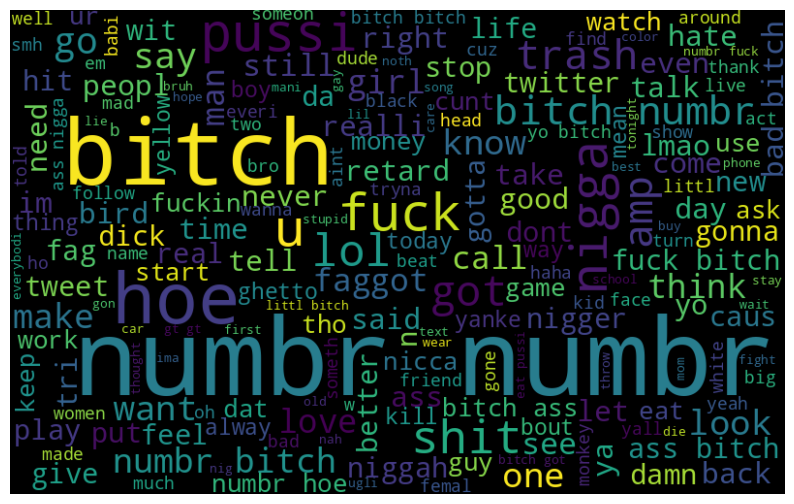

In [8]:
# visualizing which of the word is most commonly used in the twitter dataset
from wordcloud import WordCloud

all_words = ' '.join([text for text in dataset['processed_tweets'] ])
wordcloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110).generate(all_words)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

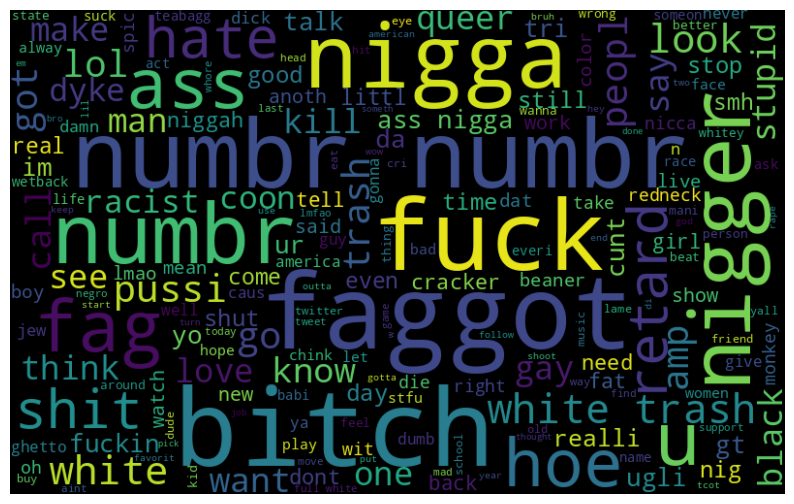

In [9]:
# visualizing which of the word is most commonly used for hatred speech
hatred_words = ' '.join([text for text in dataset['processed_tweets'][dataset['class'] == 0]])
wordcloud = WordCloud(width=800, height=500,
random_state=21, max_font_size=110).generate(hatred_words)
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

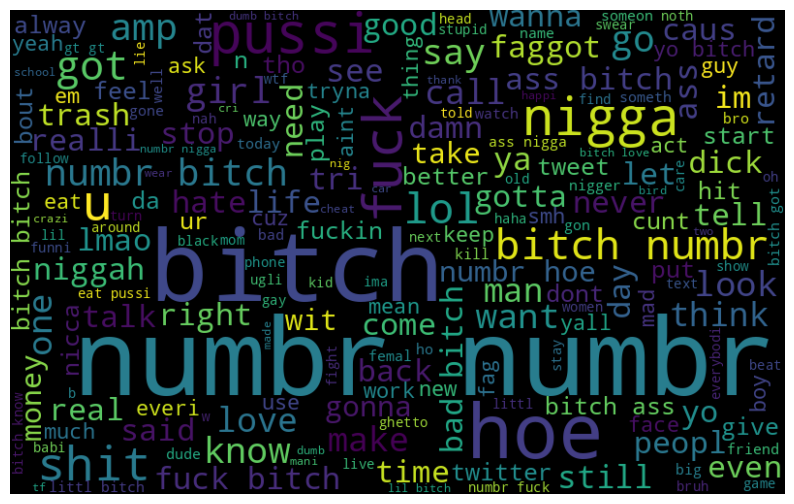

In [10]:
# visualizing which of the word is most commonly used for offensive speech
offensive_words = ' '.join([text for text in dataset['processed_tweets'][dataset['class'] == 1]])
wordcloud = WordCloud(width=800, height=500,
random_state=21, max_font_size=110).generate(offensive_words)
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

## Feature Engineering

In [11]:
#TF-IDF Features

tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2),max_df=0.75, min_df=5, max_features=10000)

# TF-IDF feature matrix
tfidf = tfidf_vectorizer.fit_transform(dataset['processed_tweets'] )
tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 206817 stored elements and shape (24783, 6938)>

### Running various model Using TFIDF

In [12]:
#logistic regression
X = tfidf
y = dataset['class'].astype(int)
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
model = LogisticRegression().fit(X_train_tfidf,y_train)
y_preds = model.predict(X_test_tfidf)
report = classification_report( y_test, y_preds )
print(report)
acc=accuracy_score(y_test,y_preds)
print("Logistic Regression, Accuracy Score:" , acc)


              precision    recall  f1-score   support

           0       0.56      0.18      0.27       290
           1       0.91      0.96      0.94      3832
           2       0.85      0.84      0.84       835

    accuracy                           0.90      4957
   macro avg       0.77      0.66      0.68      4957
weighted avg       0.88      0.90      0.88      4957

Logistic Regression, Accuracy Score: 0.8967117207988703


In [13]:
#random forest
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
rf=RandomForestClassifier()
rf.fit(X_train_tfidf,y_train)
y_preds = rf.predict(X_test_tfidf)
acc1=accuracy_score(y_test,y_preds)
report = classification_report( y_test, y_preds )
print(report)
print("Random Forest, Accuracy Score:",acc1)

              precision    recall  f1-score   support

           0       0.55      0.19      0.28       290
           1       0.93      0.96      0.94      3832
           2       0.83      0.91      0.87       835

    accuracy                           0.90      4957
   macro avg       0.77      0.68      0.70      4957
weighted avg       0.89      0.90      0.89      4957

Random Forest, Accuracy Score: 0.9039741779301997


In [14]:
#decision tree classifier
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)
d=DecisionTreeClassifier()
d.fit(X_train_tfidf,y_train)
y_preds = d.predict(X_test_tfidf)
acc2=accuracy_score(y_test,y_preds)
report = classification_report( y_test, y_preds )
print(report)
print("Decision Tree Classifier, Accuracy Score:",acc2)

              precision    recall  f1-score   support

           0       0.34      0.27      0.30       290
           1       0.92      0.94      0.93      3832
           2       0.83      0.84      0.83       835

    accuracy                           0.88      4957
   macro avg       0.70      0.68      0.69      4957
weighted avg       0.87      0.88      0.88      4957

Decision Tree Classifier, Accuracy Score: 0.880371192253379


In [15]:
#naive bayes
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X.toarray(), y, random_state=42, test_size=0.2)
nb=GaussianNB()
nb.fit(X_train_tfidf,y_train)
y_preds = nb.predict(X_test_tfidf)
acc3=accuracy_score(y_test,y_preds)
report = classification_report( y_test, y_preds )
print(report)
print("Naive Bayes, Accuracy Score:",acc3)

              precision    recall  f1-score   support

           0       0.11      0.38      0.17       290
           1       0.89      0.71      0.79      3832
           2       0.56      0.58      0.57       835

    accuracy                           0.67      4957
   macro avg       0.52      0.56      0.51      4957
weighted avg       0.79      0.67      0.71      4957

Naive Bayes, Accuracy Score: 0.6659269719588461


In [16]:
#svm
support =LinearSVC(random_state=20)
support.fit(X_train_tfidf,y_train)
y_preds = support.predict(X_test_tfidf)
acc4=accuracy_score(y_test,y_preds)
report = classification_report( y_test, y_preds )
print(report)
print("SVM, Accuracy Score:" , acc4)

              precision    recall  f1-score   support

           0       0.44      0.26      0.32       290
           1       0.92      0.95      0.94      3832
           2       0.83      0.83      0.83       835

    accuracy                           0.89      4957
   macro avg       0.73      0.68      0.70      4957
weighted avg       0.88      0.89      0.88      4957

SVM, Accuracy Score: 0.8898527335081703


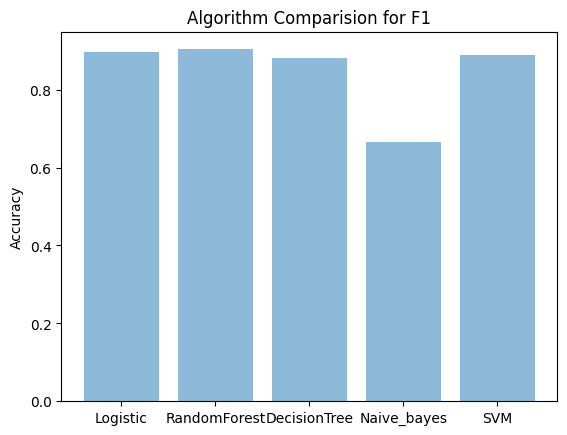

In [17]:
objects = ('Logistic', 'RandomForest', 'DecisionTree','Naive_bayes', 'SVM')
y_pos = np.arange(len(objects))
performance = [acc,acc1,acc2,acc3,acc4]
plt.bar(y_pos, performance, align='center', alpha=0.5)
plt.xticks(y_pos, objects)
plt.ylabel('Accuracy')
plt.title('Algorithm Comparision for F1')
plt.show()

### Sentiment Analysis, using polarity scores as features

In [18]:
pip install vaderSentiment


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.6 MB/s eta 0:00:00


In [19]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize VADER sentiment analyzer
sentiment_analyzer = SentimentIntensityAnalyzer()

# Function to get sentiment scores for a single tweet
def sentiment_analysis(tweet):
    sentiment = sentiment_analyzer.polarity_scores(tweet)
    return [
        sentiment['neg'],
        sentiment['pos'],
        sentiment['neu'],
        sentiment['compound']
    ]

# Function to apply sentiment analysis to a list of tweets
def sentiment_analysis_array(tweets):
    features = [sentiment_analysis(t) for t in tweets]
    return np.array(features)

# Function to assign sentiment label from compound score
def get_sentiment_label(compound_score):
    if compound_score >= 0.05:
        return "positive"
    elif compound_score <= -0.05:
        return "negative"
    else:
        return "neutral"

final_features = sentiment_analysis_array(dataset['tweet'])

# Create DataFrame from sentiment features
new_features = pd.DataFrame({
    'Neg': final_features[:, 0],
    'Pos': final_features[:, 1],
    'Neu': final_features[:, 2],
    'Compound': final_features[:, 3]
})

# Add sentiment label column
new_features['Sentiment'] = new_features['Compound'].apply(get_sentiment_label)

# Preview the result
print(new_features.head())

     Neg    Pos    Neu  Compound Sentiment
0  0.000  0.111  0.889    0.4563  positive
1  0.237  0.000  0.763   -0.6876  negative
2  0.522  0.000  0.478   -0.9550  negative
3  0.000  0.314  0.686    0.5673  positive
4  0.109  0.229  0.662    0.6331  positive


In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
new_features['Sentiment_encoded'] = le.fit_transform(new_features['Sentiment'])
new_features['Sentiment_encoded']

,Sentiment_encoded
0,2
1,0
2,0
3,2
4,2
...,...
24778,1
24779,0
24780,2
24781,0


In [21]:
tfidf_a = tfidf.toarray()
modelling_features = np.concatenate([
    tfidf_a,
    new_features[['Neg', 'Pos', 'Neu', 'Compound', 'Sentiment_encoded']]
], axis=1)
modelling_features.shape

(24783, 6943)

In [22]:

dataset["labels"] = dataset['class'].map({0: "Hate Speech", 1: "Offensive Speech", 2: "No Hate and Offensive Speech"})
dataset = dataset[["tweet", "labels"]]
print(dataset.head())


                                               tweet  \
0  !!! RT @mayasolovely: As a woman you shouldn't...   
1  !!!!! RT @mleew17: boy dats cold...tyga dwn ba...   
2  !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...   
3  !!!!!!!!! RT @C_G_Anderson: @viva_based she lo...   
4  !!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...   

                         labels  
0  No Hate and Offensive Speech  
1              Offensive Speech  
2              Offensive Speech  
3              Offensive Speech  
4              Offensive Speech  


In [23]:
X=modelling_features
y=np.array(dataset["labels"])
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

In [24]:
#Model building
model1 = RandomForestClassifier()
#training the model
model1.fit(X_train,y_train)

RandomForestClassifier()

In [25]:
#testing the model
y_pred = model1.predict(X_test)
y_pred

array(['Offensive Speech', 'Offensive Speech',
       'No Hate and Offensive Speech', ..., 'Offensive Speech',
       'Offensive Speech', 'Offensive Speech'], dtype=object)

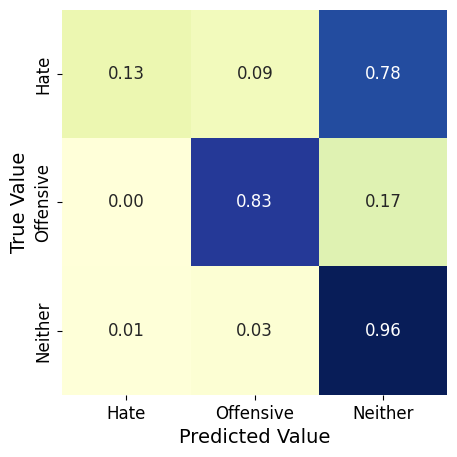

In [28]:
#Confusion Matrix for TFIDF with additional features
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test,y_pred)
matrix_proportions = np.zeros((3,3))
for i in range(0,3):
    matrix_proportions[i,:] = confusion_matrix[i,:]/float(confusion_matrix[i,:].sum())
names=['Hate','Offensive','Neither']
confusion_df = pd.DataFrame(matrix_proportions, index=names,columns=names)
plt.figure(figsize=(5,5))
sns.heatmap(confusion_df,annot=True,annot_kws={"size": 12},cmap='YlGnBu',cbar=False, square=True,fmt='.2f')
plt.ylabel(r'True Value',fontsize=14)
plt.xlabel(r'Predicted Value',fontsize=14)
plt.tick_params(labelsize=12)

In [31]:
#predicting the outcome
inp = "FUCK YOU"
tfidf_inp = tfidf_vectorizer.transform([inp]).toarray()
#print(model1.predict(inp))
sentiment_scores = sentiment_analysis(inp)
sentiment_features = np.array([sentiment_scores])  # [[neg, pos, neu, compound]]

# Get encoded sentiment label (if used during training)
compound = sentiment_scores[3]
sentiment_label = get_sentiment_label(compound)
sentiment_encoded = le.transform([sentiment_label]).reshape(1, 1)

# Combine all features
final_input = np.concatenate([tfidf_inp, sentiment_features, sentiment_encoded], axis=1)

# Predict
print(model1.predict(final_input))

['Offensive Speech']
